# Data Processing

This notebook will cover the data processing and analysis procedures.

## Table of contents

1. [Introduction](#1-introduction)
2. [Frameworks and Libraries](#2-frameworks-and-libraries)
3. [Configuration](#3-configuration)
4. [Helpers](#4-helpers)
5. [General Analysis of the data](#5-general-analysis-of-the-data)
    - 5.1. [Folder overview](#51-folder-overview)
    - 5.2. [Duplicates of patient 135](#52-duplicates-of-patient-135)
    - 5.3. [DB files without a valid extension](#53-db-files-without-a-valid-extension)
    - 5.4. [Versions of the clinical database](#54-versions-of-the-clinical-database)
    - 5.5. [12-lead ECGs and pickled files](#55-12-lead-ecgs-and-pickled-files)
    - 5.6. [ECGs folder (.don and .err files)](#56-ecgs-folder-don-and-err-files)
    - 5.7. [Quality annotations](#57-quality-annotations)
6. [Readers](#6-readers)
7. [Recording index](#7-recording-index)
    - 7.1. [Building the index](#71-building-the-index)
    - 7.2. [Signal check](#72-signal-check)
    - 7.3. [Checking bad scores](#73-checking-bad-scores)
8. [Lost packets](#8-lost-packets)
    - 8.1. [Plotting the gaps](#81-plotting-the-gaps)
    - 8.2. [Zero-filled packets](#82-zero-filled-packets)
    - 8.3. [The heart cycle in a clean recording](#83-the-heart-cycle-in-a-clean-recording)


...


### 1. Introduction
[[go back to the top]](#table-of-contents)

**The data in one paragraph.** About 300 patients from Unidade Local de Saúde de Gaia e Espinho had their heart sounds (PCG) and electrocardiogram (ECG) recorded at the same time, at the four classic auscultation sites, **aortic**, **pulmonary**, **tricuspid** and **mitral**. Each patient also had an echocardiogram, and its measurements and written report are stored in a clinical spreadsheet. The recordings were made with two different apps that save the signals in different formats, so part of the work here is simply bringing both into the same shape.


### 2. Frameworks and Libraries
[[go back to the top]](#table-of-contents)

In [18]:
# Standard library
import re
import unicodedata
import filecmp
from dataclasses import dataclass, field
from pathlib import Path
from scipy.signal import butter, filtfilt, find_peaks


# Third party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf

### 3. Configuration
[[go back to the top]](#table-of-contents)

The dataset folder was reorganized once with **`scripts/organize_data.py`**, so this notebook expects the following layout. If you start from a fresh copy of the data, run `python scripts/organize_data.py --dry-run` to see the plan, and then run it without the flag [`--dry-run`].

```
data/DatasetCHVNGE/
├── New_app_patients/        one folder per patient (109+), ECG and PCG CSVs
├── Rijuven_patients/        Rijuven .raw (ECG) and .mp3 (PCG) files
├── DB_Multiscope/           clinical database, every version (copies found in patient folders start with 'from_<ID>_')
├── Patients_Multiscope/     patient list (contains names, used only for de-identification)
├── README/                  notes about the data
├── Duplicates/              loose copies of files that already exist in a patient folder
└── ...                      12-lead ECG folders, quality annotations
```

In [2]:
# Project root: first folder, from the notebook location upwards, that contains a "data" folder
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "data").is_dir())

DATA_ROOT = PROJECT_ROOT / "data" / "DatasetCHVNGE"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"   # de-identified tables are saved here
CHECKS_FILE = OUTPUT_DIR / "recording_checks.pkl"   # delete this file to recompute

NEW_APP_DIR = DATA_ROOT / "New_app_patients"
RIJUVEN_DIR = DATA_ROOT / "Rijuven_patients"
DB_DIR = DATA_ROOT / "DB_Multiscope"
PATIENTS_DIR = DATA_ROOT / "Patients_Multiscope"

QUALITY_DIR = DATA_ROOT / "Quality_Annotations"

DUPLICATES_DIR = DATA_ROOT / "Duplicates"
NEW_12_LEAD_DIR = DATA_ROOT / "New_12_lead_ECG"
OLD_12_LEAD_DIR = DATA_ROOT / "Old_12_lead_ECG"
SAMSUNG_DIR = DATA_ROOT / "Samsung_12_lead_ECG"
ECGS_DIR = DATA_ROOT / "ECGs" / "ecgs_01-02-2025_11-06-2025"
PICKLED_DIR = DATA_ROOT / "pickled"

CLINICAL_DB_GLOB = "21.07.2026_DB MultiScope*.xlsx"   # latest version of the clinical database
PATIENT_LIST_GLOB = "Patients_MultiScope*.xlsx"
REPORT_COLUMN = "Report_ecoTT"                        # free-text echocardiography report
IDENTIFIER_COLUMNS = ["NAME", "NSC", "PROC", "Birthday"]

RIJUVEN_ECG_FS = 500   # not stored in the .raw files, value from the original script
NO_SIGNAL_IDS = [71, 72, 73, 74, 75, 76, 77, 131, 132]   # patients without ECG/PCG recordings

for folder in (NEW_APP_DIR, RIJUVEN_DIR, DB_DIR, PATIENTS_DIR):
    assert folder.is_dir(), f"Missing folder: {folder} (run scripts/organize_data.py first)"
print("Dataset root:", DATA_ROOT)

Dataset root: c:\Users\aleja\OneDrive\Documentos\GitHub\cardio-trimodal-align\data\DatasetCHVNGE


### 4. Helpers
[[go back to the top]](#table-of-contents)

For privacy, I ensure that any private information (such as names, birthdate, etc...) is not printed in this notebook.

In [3]:
# Column names that identify a patient (compared in lowercase)
IDENTIFIER_NAMES = {"name", "nome", "nsc", "proc", "birthday", "data de nascimento"}

# Every valve spelling used by both apps, mapped to one code
SITE_MAP = {"av": "AV", "aortica": "AV", "mv": "MV", "mitral": "MV",
            "pv": "PV", "pulmonar": "PV", "tv": "TV", "tricuspide": "TV"}

def drop_identifiers(df: pd.DataFrame) -> pd.DataFrame:
    """Remove the columns that identify a patient."""
    keep = [c for c in df.columns if str(c).strip().lower() not in IDENTIFIER_NAMES]
    return df[keep]


def read_table(path: Path, **kwargs) -> pd.DataFrame:
    """Read a spreadsheet without its identifier columns."""
    return drop_identifiers(pd.read_excel(path, **kwargs))

def describe_object(obj) -> str:
    """Short description of an unpickled object: type, shape or keys."""
    if isinstance(obj, pd.DataFrame):
        return f"DataFrame {obj.shape}, columns: {list(obj.columns)[:10]}"
    if isinstance(obj, np.ndarray):
        return f"ndarray {obj.shape}, dtype {obj.dtype}"
    if isinstance(obj, dict):
        return f"dict with {len(obj)} keys, first: {list(obj)[:5]}"
    if isinstance(obj, (list, tuple)):
        return f"{type(obj).__name__} with {len(obj)} items"
    return type(obj).__name__


def load_db_version(path: Path) -> pd.DataFrame:
    """One DB version without identifiers, one row per numeric ID."""
    df = read_table(path)
    df["ID"] = pd.to_numeric(df["ID"], errors="coerce")
    return df.dropna(subset=["ID"]).astype({"ID": int}).drop_duplicates("ID")


def comparable(df: pd.DataFrame) -> pd.DataFrame:
    """Values as text, so that 1 and 1.0 (or NaN and None) compare equal."""
    num = df.apply(pd.to_numeric, errors="coerce")
    text = df.astype(str).apply(lambda s: s.str.strip())
    out = text.where(num.isna(), num.astype(float).astype(str))
    return out.where(df.notna(), "")


def count_changes(old: pd.DataFrame, new: pd.DataFrame) -> int:
    """Number of values that differ between two versions, on the patients and columns they share."""
    old, new = old.set_index("ID"), new.set_index("ID")
    ids = old.index.intersection(new.index)
    cols = old.columns.intersection(new.columns)
    return int((comparable(old.loc[ids, cols]) != comparable(new.loc[ids, cols])).to_numpy().sum())

def natural_key(path: Path) -> list:
    """Sort key that compares the numbers in a file name as numbers: '2_x' before '10_x'."""
    return [int(part) if part.isdigit() else part.lower() for part in re.split(r"(\d+)", path.name)]


def read_text(path: Path) -> str:
    """Read a text file as UTF-8, falling back to Latin-1 for older exports."""
    try:
        return path.read_text(encoding="utf-8-sig")
    except UnicodeDecodeError:
        return path.read_text(encoding="latin-1")


def parse_number(value: str | None) -> float | None:
    """Extract the number from header values such as '500Hz' -> 500.0"""
    match = re.search(r"\d+(?:\.\d+)?", value or "")
    return float(match.group()) if match else None


def normalize_site(name) -> str | None:
    """Common valve code ('Aórtica' -> 'AV'), None if empty."""
    clean = unicodedata.normalize("NFKD", str(name)).encode("ascii", "ignore").decode().strip().lower()
    return None if clean in ("", "nan") else SITE_MAP.get(clean, str(name))

### 5. General Analysis of the data
[[go back to the top]](#table-of-contents)

In this section, I analyze the data downloaded from **INESC TEC** as it came, before any processing. In a first look, I noticed:

- **Duplicate files of patient 135:** 8 signal CSVs were loose in the dataset root, with the same names as files inside folder `135` (moved to `Duplicates/`).

- **Two files without a valid extension:** `DB MultiScope Class HTP` and `DB MultiScope Class HTP_30.05.2025`, which do not open in Excel.

- **Many versions of the clinical database:** 16 `DB MultiScope` spreadsheets from different dates, plus 5 more copies saved by mistake inside patient folders 110, 112, 113, 114 and 134 (moved to `DB_Multiscope/`, with names starting with `from_<ID>_`).

- **12-lead ECGs:** by reading the [[README_12_lead_ECG.docx]](data/DatasetCHVNGE/New_12_lead_ECG/README_12_lead_ECG.docx), the 12-lead ECGs were recorded at the hospital with two **Mortara electrocardiographs** (ELI 350 and ELI 250c) and are stored as `.pkl` files at 1000 Hz in `New_12_lead_ECG/`. `Old_12_lead_ECG/` is an older version that **should not be used**, as stated in the document. Several time windows around the evaluation date were tested (761, 30, 10 and 5 days), and only ECGs taken **within 5 days** were kept, so many patients have no 12-lead ECG (e.g. 131, 132, 133 and most patients from 142 onwards), and patients 3, 24, 69 and 70 are in the database but outside this window. When several ECGs were taken on the same day, the one closest to the evaluation date was chosen. For patients 5, 13, 15 and 43 the NSC in the ECG file does not match the database (13, 15 and 43 also have different birth dates), so these ECGs may belong to someone else.

- **A large `ECGs/` folder:** about 11 000 `.don` and 400 `.err` files, in a format I did not recognize.

- **Patients without signals and repeated recordings:** according to the [[README.docx]](data/DatasetCHVNGE/README/README.docx), IDs 71 to 77 have no ECG or PCG due to an app problem, and some patients have more than one recording at the same valve (e.g. 10, 16, 18, 35, 39, 86, 125, 130).

- **Patient list:** `Patients_MultiScope` has its header on the second row and contains names and health numbers.

#### 5.1. Folder overview
[[go back to the topic]](#5-general-analysis-of-the-data)

Number of files and total size per folder and extension.

In [13]:
files = [p for p in DATA_ROOT.rglob("*") if p.is_file()]

overview = pd.DataFrame({
    "folder": [p.relative_to(DATA_ROOT).parts[0] if p.parent != DATA_ROOT else "(root)" for p in files],
    "ext": [p.suffix.lower() or "(none)" for p in files],
    "size_mb": [p.stat().st_size / 1e6 for p in files],
})

overview.groupby(["folder", "ext"]).agg(files=("size_mb", "size"), size_mb=("size_mb", "sum")).round(1)

files  size_mb
folder              ext                   
(root)              (none)      1      0.1
                    .2025       1      0.1
                    .docx       1      0.0
DB_Multiscope       .xlsx      21      2.9
Duplicates          .csv        8      1.9
ECGs                .don    10960   5734.0
                    .err      402    209.1
New_12_lead_ECG     .docx       1      0.0
                    .pdf        2      1.6
                    .pkl      133    161.0
New_app_patients    .csv     1904    441.9
Old_12_lead_ECG     .don       49     25.4
                    .err        2      1.0
Patients_Multiscope .xlsx       1      0.0
Quality_Annotations .txt        1      0.0
                    .xlsx       2      0.1
README              .docx       1      0.0
                    .md         1      0.0
Rijuven_patients    .mp3      433     52.7
                    .raw      433     32.4
Samsung_12_lead_ECG .pkl        4      4.8
pickled             .pkl        1    338.7

#### 5.2. Duplicates of patient 135
[[go back to the topic]](#5-general-analysis-of-the-data)

Each file in `Duplicates/` is compared with the file of the same name inside the patient folders. This compares the two byte by byte. `shallow=False` matters here, without it, **filecmp** only compares size and modification date, not the content.

In [ ]:
# Compare every file in Duplicates/ with the file of the same name in the patient folders
if DUPLICATES_DIR.exists():
    rows = []
    for dup in sorted(DUPLICATES_DIR.iterdir()):
        originals = list(NEW_APP_DIR.glob(f"*/{dup.name}"))
        rows.append({
            "file": dup.name,
            "original": str(originals[0].relative_to(DATA_ROOT)) if originals else None,
            "identical": len(originals) == 1 and filecmp.cmp(dup, originals[0], shallow=False),
        })
    duplicates_check = pd.DataFrame(rows)
    print(f"Identical: {duplicates_check['identical'].sum()} of {len(duplicates_check)}")
    display(duplicates_check)
else:
    print("Duplicates/ was deleted after this check (all 8 files were identical).")

Identical: 8 of 8


,file,original,identical
0,P135_Aórtica_ECG_2023-12-19;10-14-42.6200.csv,New_app_patients\135\P135_Aórtica_ECG_2023-12-...,True
1,P135_Aórtica_PCG_2023-12-19;10-14-42.6200.csv,New_app_patients\135\P135_Aórtica_PCG_2023-12-...,True
2,P135_Mitral_ECG_2023-12-19;10-16-08.1120.csv,New_app_patients\135\P135_Mitral_ECG_2023-12-1...,True
3,P135_Mitral_ECG_2023-12-19;10-16-52.9030.csv,New_app_patients\135\P135_Mitral_ECG_2023-12-1...,True
4,P135_Mitral_PCG_2023-12-19;10-16-08.1120.csv,New_app_patients\135\P135_Mitral_PCG_2023-12-1...,True
5,P135_Mitral_PCG_2023-12-19;10-16-52.9030.csv,New_app_patients\135\P135_Mitral_PCG_2023-12-1...,True
6,P135_Pulmonar_ECG_2023-12-19;10-15-25.2520.csv,New_app_patients\135\P135_Pulmonar_ECG_2023-12...,True
7,P135_Pulmonar_PCG_2023-12-19;10-15-25.2520.csv,New_app_patients\135\P135_Pulmonar_PCG_2023-12...,True


All 8 files are identical to the originals in folder `135`, so the `Duplicates/` folder can be deleted.

#### 5.3. DB files without a valid extension
[[go back to the topic]](#5-general-analysis-of-the-data)

The first bytes of a file reveal its real format, whatever its name says: 
- `PK` means `.xlsx` (a zip);
- `\xd0\xcf\x11\xe0` means old Excel; 
- `.xls`, and readable text means CSV.

In [ ]:
# The first bytes of a file reveal its real format, regardless of the extension
DB_RENAMED = [DB_DIR / "DB MultiScope Class HTP.xlsx", DB_DIR / "DB MultiScope Class HTP_30.05.2025.xlsx"]

for path in DB_RENAMED:
    with open(path, "rb") as f:
        print(f"{path.name:45s} {f.read(8)}")

DB MultiScope Class HTP                       b'PK\x03\x04\x14\x00\x06\x00'
DB MultiScope Class HTP_30.05.2025            b'PK\x03\x04\x14\x00\x06\x00'


In [22]:
for path in sorted(DATA_ROOT.glob("DB MultiScope Class HTP*")):
    df = read_table(path, engine="openpyxl")   # engine forces the xlsx reader, whatever the extension
    print(f"{path.name:45s} {df.shape[0]} rows x {df.shape[1]} columns")

DB MultiScope Class HTP                       211 rows x 39 columns
DB MultiScope Class HTP_30.05.2025            217 rows x 39 columns


Both files start with `PK`, the signature of a zip archive, which is what an `.xlsx` file is inside. They are valid spreadsheets that lost their extension, so they were renamed to `.xlsx` and moved to `DB_Multiscope/` together with the other versions.

#### 5.4. Versions of the clinical database
[[go back to the topic]](#5-general-analysis-of-the-data)

All versions of the `DB MultiScope` spreadsheet. Every version is compared with the latest one (`21.07.2026_...`). First the shape of each file, then, for the patients and columns they share, how many values differ.

This gives us one row per version:

- **patients and columns**: the size of that version.
- **ids_not_in_latest**: patients that were dropped later. Should be 0.
- **cols_not_in_latest**: columns that were renamed or removed.
- **changed_values**: values corrected between that version and the latest.

In [30]:
versions = {p.name: load_db_version(p) for p in sorted(DB_DIR.glob("*.xls*"))}
latest = versions[next(name for name in versions if name.startswith("21.07.2026"))]

pd.DataFrame([{
    "file": name,
    "patients": len(df),
    "columns": df.shape[1],
    "ids_not_in_latest": (~df["ID"].isin(latest["ID"])).sum(),
    "cols_not_in_latest": list(df.columns.difference(latest.columns)),
    "changed_values": count_changes(df, latest),
} for name, df in versions.items()])

,file,patients,columns,ids_not_in_latest,cols_not_in_latest,changed_values
0,21.07.2026_DB MultiScope Class HTP Atualizado....,301,39,0,[],0
1,DB MultiScope Class HTP Atualizado 14.01.xlsx,267,39,0,[],1
2,DB MultiScope Class HTP Atualizado 18.11.xlsx,255,39,0,[],23
3,DB MultiScope Class HTP Atualizado 22.09.xlsx,240,39,0,[],62
4,DB MultiScope Class HTP Atualizado_20.08.xlsx,234,39,0,[],27
5,DB MultiScope Class HTP Atualizado_30.10.xlsx,249,39,0,[],87
6,DB MultiScope Class HTP.xlsx,209,39,0,[],303
7,DB MultiScope Class HTP_05.08.xlsx,226,39,0,[],38
8,DB MultiScope Class HTP_13.06.xlsx,218,39,0,[],22
9,DB MultiScope Class HTP_18.06.xlsx,223,39,0,[],24


In [5]:
def changed_columns(old: pd.DataFrame, new: pd.DataFrame) -> pd.Series:
    """Number of changed values per column."""
    old, new = old.set_index("ID"), new.set_index("ID")
    ids, cols = old.index.intersection(new.index), old.columns.intersection(new.columns)
    diff = comparable(old.loc[ids, cols]) != comparable(new.loc[ids, cols])
    return diff.sum()[lambda s: s > 0].sort_values(ascending=False)

changed_columns(versions["DB MultiScope Class HTP Atualizado_30.10.xlsx"], latest)

Alt_Valv_Aortica       11
Alt Valv Pulmonar      11
Alt Valv Tricúspide    11
Alt Valv Mitral        11
Report_ecoTT            9
Gradiente VD/AD         7
FEVE4C                  5
PSAP                    5
EcoTT                   1
protese_aortica         1
Peso                    1
Altura                  1
IAO                     1
IM                      1
IT                      1
IP                      1
FEVEBP                  1
Fluxo pulmonar          1
Dados Hemodinâmicos     1
mPAP                    1
pCWP                    1
RVP                     1
AoMeanP                 1
AoSistP                 1
AoDiastP                1
dtype: int64

All versions were compared with the latest one (`21.07.2026`), value by value, on the patients and columns they share. 

No patient was ever removed (`ids_not_in_latest` = 0), and the number of different values decreases as versions get closer to the latest, which reflects corrections made over time. I'm guessing that the `from_<ID>_` copies found in patient folders are older versions saved by mistake.

| Copy | Same as | Evidence |
|---|---|---|
| `from_110`, `from_114` | `22.09` | 240 patients, 62 changes |
| `from_113` | `HTP.xlsx` | 209 patients, 303 changes |
| `from_134` | `30.05.2025` | 215 patients, 39 changes |
| `from_112` | none exactly | 249 patients like `30.10`, but 79 changes instead of 87 |

`from_112` looks like an intermediate version between `30.10` and `18.11` that was never saved in the root. It is still older than the latest version, so it adds nothing.

**Conclusion:** the latest version is used as the only source of clinical data. The only information it lacks are about 60 extra echocardiography columns present in the early versions (`DB_MultiScope1_4` to `_9`) for the first 133 to 169 patients.

The number of patients per version is slightly lower than the number of rows in [[Section 5.3.]](#53-db-files-without-a-valid-extension) (e.g. 209 instead of 211) because `load_db_version` keeps only rows with a numeric ID and one row per patient, so empty or repeated rows are not counted.

In [18]:
db = load_db_version(next(DB_DIR.glob(CLINICAL_DB_GLOB)))
print(next(DB_DIR.glob(CLINICAL_DB_GLOB)).name)
print("Position:", list(db.columns).index(REPORT_COLUMN) if REPORT_COLUMN in db.columns else "not found")
print(list(db.columns))

21.07.2026_DB MultiScope Class HTP Atualizado.xlsx
Position: 7
['ID', 'EvaluationDate', 'Ritmo', 'EcoTT', 'Gender', 'Peso', 'Altura', 'Report_ecoTT', 'Alt_Valv_Aortica', 'Alt Valv Mitral', 'Alt Valv Pulmonar', 'Alt Valv Tricúspide', 'protese_aortica', 'FEVE4C', 'FEVEBP', 'IAO', 'IM', 'IT', 'IP', 'Fluxo pulmonar', 'Gradiente VD/AD', 'PSAP', 'Smoking', 'HTA', 'Hyperuricemia', 'Dyslipidemia', 'Diabetes', 'Hx_CAD', 'Hx_stroke', 'PAD', 'Dados Hemodinâmicos', 'mPAP', 'pCWP', 'RVP', 'AoMeanP', 'AoSistP', 'AoDiastP', 'VMaxRegTric', 'HTP Probability']


#### 5.5. 12-lead ECGs and pickled files
[[go back to the topic]](#5-general-analysis-of-the-data)

What is inside the first `.pkl` file of each folder. Only the structure is printed (type, shape, column names), not the values.

In [26]:
for folder in (NEW_12_LEAD_DIR, SAMSUNG_DIR, PICKLED_DIR):
    pkl_files = sorted(folder.glob("*.pkl"), key=natural_key)
    first = pkl_files[0]
    print(f"{folder.name}: {len(pkl_files)} files")
    print(f"   {first.name}: {describe_object(pd.read_pickle(first))}\n")

New_12_lead_ECG: 133 files
   1_12_lead_ECG_05_04_2023.pkl: dict with 27 keys, first: ['date_don_file', 'time', 'final_id', 'ECG_lead_I', 'ECG_lead_II']

Samsung_12_lead_ECG: 4 files
   30_12_lead_ECG_14_05_2025.pkl: dict with 27 keys, first: ['date_don_file', 'time', 'final_id', 'ECG_lead_I', 'ECG_lead_II']

pickled: 1 files
   compiled_dataset.pkl: DataFrame (816, 5), columns: ['ID', 'Auscultation_Point', 'Source', 'ECG', 'PCG']



**12-lead ECG files.** Each `.pkl` is one 12-lead exam stored as a dict, the exam date and time, an ID (`final_id`), 12 leads of 10 000 samples (10 s at 1000 Hz, the "Best 10" seconds selected by the Mortara device) and 12 representative beats of 1200 samples (1.2 s), an average heartbeat per lead computed by the device. The 4 files in `Samsung_12_lead_ECG/` have the same structure, the origin of the name is still to be confirmed.


In [27]:
# Keys of one 12-lead ECG file: type and size of each, no values
ecg12 = pd.read_pickle(sorted(NEW_12_LEAD_DIR.glob("*.pkl"), key=natural_key)[0])
pd.DataFrame([{"key": k, "type": type(v).__name__, "size": np.shape(v)} for k, v in ecg12.items()])

,key,type,size
0,date_don_file,str,()
1,time,str,()
2,final_id,int,()
3,ECG_lead_I,list,"(10000,)"
4,ECG_lead_II,list,"(10000,)"
5,ECG_lead_III,list,"(10000,)"
6,ECG_lead_AVR,list,"(10000,)"
7,ECG_lead_AVL,list,"(10000,)"
8,ECG_lead_AVF,list,"(10000,)"
9,ECG_lead_V1,list,"(10000,)"


In [32]:
# The compiled dataset: one row per recording, with the signals stored inside the table
compiled = pd.read_pickle(PICKLED_DIR / "compiled_dataset.pkl")

ids = pd.to_numeric(compiled["ID"], errors="coerce")   # IDs are stored as text
print(f"Patients: {ids.nunique()} (IDs {ids.min():.0f} to {ids.max():.0f}) | non-numeric IDs: {ids.isna().sum()}")
print(compiled["Source"].value_counts(), "\n")
print(compiled["Auscultation_Point"].value_counts(), "\n")
print("ECG cell:", describe_object(compiled["ECG"].iloc[0]), "| PCG cell:", describe_object(compiled["PCG"].iloc[0]))

Patients: 186 (IDs 1 to 195) | non-numeric IDs: 0
Source
Rijuven     417
INESCTEC    399
Name: count, dtype: int64 

Auscultation_Point
AV      186
MV      186
PV      186
TV      184
AV_2     24
PV_2     20
TV_2     14
MV_2     10
AV_3      5
PV_3      1
Name: count, dtype: int64 

ECG cell: ndarray (15375,), dtype int32 | PCG cell: ndarray (245997,), dtype int16


**`compiled_dataset.pkl`.** Is an older compilation of the synchronous recordings, made when the dataset reached patient 195, 816 recordings from 186 patients (IDs 1 to 195, without 71 to 77, which have no signals), with ID, auscultation point (`AV_2`, `PV_3`, ... for repeated recordings), source app and the ECG and PCG signals as arrays. The IDs are stored as text and the sampling rates are not stored, so this file is only used as a cross-check of the loaders, not as a data source.


But they have 9 missing IDs, lets check the other two IDs.

In [33]:
sorted(set(range(1, 196)) - set(ids.astype(int)))

[71, 72, 73, 74, 75, 76, 77, 131, 132]

In [34]:
[(NEW_APP_DIR / str(pid)).is_dir() for pid in (131, 132)]

[False, False]

So patient 131 and 132 don't have signals at all, and it can be confirmed in the folder `New_app_patients`. Let's check if its in the `Rijuven_patients` folder.

In [35]:
sorted(p.name for p in RIJUVEN_DIR.glob("13[12]_*"))

[]

It's not, so not only IDs 71-77 don't have signals as stated in [[README.docx]](data/DatasetCHVNGE/README/README.docx), but also patients 131 and 132, don't have. This last case is not documented in the README.

#### 5.6. ECGs folder (.don and .err files)
[[go back to the topic]](#5-general-analysis-of-the-data)

The first bytes of one `.don` and one `.err` file, to find out whether they are text or binary.

In [21]:
for ext in (".don", ".err"):
    path = next(ECGS_DIR.glob(f"*{ext}"))
    print(f"{ext}: {path.stat().st_size / 1e3:.0f} KB")
    print(path.read_bytes()[:300], "\n")

.don: 517 KB
b'<?xml version="1.0" encoding="UTF-8" standalone="yes"?>\n<AnnotatedECG xsi:schemaLocation="urn:hl7-org:v3 PORT_MT020001.xsd" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance">\n    <id root="3b862b5a-e590-4acf-b18e-4838c95d17a4"/>\n    <code code="93000" codeSystem="2.16.840.1.113883.6.12" codeSyst' 

.err: 501 KB
b'<?xml version="1.0" encoding="UTF-8" standalone="yes"?>\n<AnnotatedECG xsi:schemaLocation="urn:hl7-org:v3 PORT_MT020001.xsd" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance">\n    <id root="add3d34a-07bc-4f26-8730-6349523a9dcb"/>\n    <code code="93000" codeSystem="2.16.840.1.113883.6.12" codeSyst' 



The `.don` and `.err` files are XML in the HL7 aECG standard (Annotated ECG), the raw 12-lead ECG exports from the hospital. The `.pkl` files in `New_12_lead_ECG/` were built from them (their first key is `date_don_file`), so the `.pkl` files are used instead. Raw exports usually include patient demographics, so their content is not printed here.

#### 5.7. Quality annotations
[[go back to the topic]](#5-general-analysis-of-the-data)

What the quality annotation files contain, the text file in full, and the size, columns and first rows of each spreadsheet.

In [46]:
for path in sorted(QUALITY_DIR.glob("*.txt")):
    print(f"--- {path.name}\n{read_text(path)}\n")

for path in sorted(QUALITY_DIR.glob("*.xlsx")):
    df = read_table(path)
    print(f"--- {path.name}: {df.shape[0]} rows x {df.shape[1]} columns")
    display(df.head())

--- SQ_manual_annotation_system.txt
# Signal Quality manual Annotation Scoring System

## Score 0

- No relevant information present neither ECG or PCG

## Score 1

- _ECG_: **Just** R-peak noticeable with very irritating impairments
- _PCG_: S1 **or** S2 with very irritating impairments

## Score 2

- _ECG_: **Just** QRS noticeable with irritating impairments
- _PCG_: S1 **or** S2 with slightly irritating impairments

## Score 3

- _ECG_: QRS + T-wave with slightly irritating impairments
- _PCG_: S1 **and** S2 with irritating impairments

## Score 4

- _ECG_: QRS + T-wave with perceptible impairments but not irritating
- _PCG_: S1 **and** S2 with perceptible impairments but not irritating

## Score 5

- _ECG_: QRS + T-wave with imperceptible impairments
- _PCG_: S1 **and** S2 with imperceptible impairments

## Score 2




--- ULSGE_manual_SQA.xlsx: 824 rows x 5 columns


,Trial,Spot,ECG,PCG,mSQA_min
0,1,AV,2.0,1.0,1.0
1,1,PV,4.0,4.0,4.0
2,1,TV,4.0,3.0,3.0
3,1,MV,3.0,3.0,3.0
4,2,AV,0.0,3.0,0.0


--- ULSGE_manual_SQA_ver_2.xlsx: 1227 rows x 5 columns


,Trial,Spot,ECG,PCG,mSQA_min
0,1,AV,2,1,1
1,1,PV,4,4,4
2,1,TV,4,3,3
3,1,MV,3,3,3
4,2,AV,0,3,0


`Quality_Annotations/` contains a manual **signal quality assessment** (SQA) of the recordings, not a quality check of annotations. Each ECG and PCG was scored from 0 (no usable information) to 5 (clean signal, with QRS and T wave visible in the ECG and S1 and S2 in the PCG), following the scale in `SQ_manual_annotation_system.txt`. 

`mSQA_min` is the lower of the two scores, since a recording is only as usable as its worst signal. `ULSGE_manual_SQA_ver_2.xlsx` is the extended version (1227 recordings) and is the one used. These scores can be used later to exclude low-quality recordings or to study how quality affects the models.


In [54]:
sqa_raw = read_table(QUALITY_DIR / "ULSGE_manual_SQA_ver_2.xlsx")

print(f"Patients: {sqa_raw['Trial'].nunique()} (IDs {sqa_raw['Trial'].min()} to {sqa_raw['Trial'].max()})")
print("Spots:", sorted(sqa_raw["Spot"].unique()))
sqa_raw[["ECG", "PCG", "mSQA_min"]].apply(lambda s: s.value_counts()).sort_index()

Patients: 267 (IDs 1 to 267)
Spots: ['AV', 'AV1', 'AV2', 'AV3', 'MV', 'MV ', 'MV1', 'MV2', 'MV3', 'PV', 'PV1', 'PV2', 'PV3', 'PV\xa0', 'TV', 'TV1', 'TV2']


,ECG,PCG,mSQA_min
0,314,233,448
1,258,342,363
2,208,239,219
3,242,277,150
4,144,105,42
5,61,31,5


This output shows us 3 things.

**1. Coverage.** The annotations cover patients 1 to 267, so patients 268 onwards are not annotated yet. Since there are 267 different IDs between 1 and 267, every ID appears, including 71 to 77, 131 and 132, which have no recordings. Checking their rows:

In [55]:
sqa_raw[sqa_raw["Trial"].isin(NO_SIGNAL_IDS)]

,Trial,Spot,ECG,PCG,mSQA_min
290,71,AV,0,0,0
291,71,PV,0,0,0
292,71,TV,0,0,0
293,71,MV,0,0,0
294,72,AV,0,0,0
295,72,PV,0,0,0
296,72,TV,0,0,0
297,72,MV,0,0,0
298,73,AV,0,0,0
299,73,PV,0,0,0


And that confirms it, these are placeholder rows, not real scores. Patients 71–77, 131 and 132 have no recordings, so they got 0 in everything. That's 36 rows (9 patients × 4 sites), and they inflate the zeros in the table. So, let's remove them after point 3. 

**2.** The spot names are messy. There are three problems:
- 'MV ' has a trailing space, and 'PV\xa0' has an invisible non-breaking space.
- Repeated recordings are named AV1, AV2, AV3. The compiled dataset used AV_2 and AV_3.
- AV and AV1 both exist, so it's unclear whether AV1 is the first recording or the second.

The spaces are easy to fix. strip() also removes the invisible one:

In [14]:
sqa = sqa_raw.copy()                     # working copy, sqa_raw stays as the original file
sqa["Spot"] = sqa["Spot"].str.strip()
sorted(sqa["Spot"].unique())

['AV',
 'AV1',
 'AV2',
 'AV3',
 'MV',
 'MV1',
 'MV2',
 'MV3',
 'PV',
 'PV1',
 'PV2',
 'PV3',
 'TV',
 'TV1',
 'TV2']

How to match AV, AV1, AV2 to the actual recordings will be decided when we join this with the recording index [[Section 7]](#7-recording-index).

**3.** Most recordings have low quality. This is the important finding. The placeholder rows of patients 71–77, 131 and 132 are removed first, since they would inflate the zeros, and then the share of recordings per overall score (`mSQA_min`) is computed, with 4 and 5 grouped as "3 or more".

In [57]:
sqa = sqa[~sqa["Trial"].isin(NO_SIGNAL_IDS)]
sqa[["ECG", "PCG", "mSQA_min"]].apply(lambda s: s.value_counts()).sort_index()

,ECG,PCG,mSQA_min
0,278,197,412
1,258,342,363
2,208,239,219
3,242,277,150
4,144,105,42
5,61,31,5


In [58]:
overall = sqa["mSQA_min"].clip(upper=3).value_counts().sort_index()   # 4 and 5 counted as 3, i.e. "3 or more"
pd.DataFrame({"recordings": overall, "share_%": (100 * overall / overall.sum()).round(1)})

,recordings,share_%
mSQA_min,,
0,412,34.6
1,363,30.5
2,219,18.4
3,197,16.5


34.6% of the recordings have an overall score of 0 and 30.5% a score of 1, so two thirds have at least one signal with no usable information or only isolated beats. 

Only 18.4% score 2 and 16.5% score 3 or more. The ECG has more zero scores (278) than the PCG (197), which is surprising, since the ECG is usually the easier signal to record. Once the recording index exists, it is worth checking whether the bad scores concentrate in one app.

This limits how many recordings can be used and will be considered when selecting data for the models.

### 6. Readers
[[go back to the top]](#table-of-contents)

The two apps save the signals in different formats, so each format has its own reader. All readers return the same thing, a `Signal`, so the rest of the notebook does not need to know which app recorded what.

| App | ECG | PCG |
|---|---|---|
| Rijuven | `.raw`: plain text, numbers separated by commas, no sampling rate stored (500 Hz) | `.mp3`: compressed audio, the sampling rate is stored in the file |
| New app | `.csv`: a header with `key=value` lines, then one row per packet | same format as the ECG |

**The `Signal` container.** Groups the samples (`data`), the sampling rate in Hz (`fs`) and any extra information from the file (`meta`). The duration in seconds is the number of samples divided by the sampling rate.

In [4]:
@dataclass
class Signal:
    data: np.ndarray
    fs: float
    meta: dict = field(default_factory=dict)

    @property
    def duration(self) -> float:
        return len(self.data) / self.fs

**New app reader.** A new app CSV starts with header lines such as `Sampling_frequency=500Hz` or `Test_valve=Mitral`. After the header, the signal arrives in packets, each row starts with the time the packet arrived (`2023-11-29 11:31:13.7450`) followed by its samples. 

The reader keeps the header in a dictionary, joins all packets in order into one array and reads the sampling rate from the header. Rows are recognized by their timestamp, not by the year, so recordings from any year are read.

In [5]:
TIMESTAMP_RE = re.compile(r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}")   # a data row starts with a timestamp


def read_new_app_csv(path: Path) -> Signal:
    header, packet_times, packets = {}, [], []
    for line in read_text(path).splitlines():
        line = line.strip().rstrip(",")
        if TIMESTAMP_RE.match(line):
            stamp, *values = line.split(",")
            packet_times.append(stamp)
            packets.append(np.array([v for v in values if v.strip()], dtype=float))
        elif "=" in line:
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    fs = parse_number(header.get("Sampling_frequency"))
    data = np.concatenate(packets) if packets else np.empty(0)
    return Signal(data, fs, {"header": header, "packet_times": packet_times,
                         "packet_sizes": [len(p) for p in packets]})

**Rijuven readers.** The ECG `.raw` file is just a long list of numbers separated by commas, it does not store the sampling rate, so the 500 Hz from the professor's script is used. The PCG `.mp3` is decoded with `soundfile`, which also returns its sampling rate. If the audio has two channels (stereo), they are averaged into one.

In [6]:
def read_rijuven_ecg(path: Path) -> Signal:
    values = [v for v in re.split(r"[,\s]+", read_text(path).strip()) if v]
    return Signal(np.array(values, dtype=float), RIJUVEN_ECG_FS)


def read_rijuven_pcg(path: Path) -> Signal:
    data, fs = sf.read(path, always_2d=True)   # shape (samples, channels), at the native sampling rate
    return Signal(data.mean(axis=1), float(fs))

**Loading a recording.** Given one row of the recording index ([[Section 7]](#7-recording-index)), loads its ECG and PCG with the right readers for its app, so the rest of the notebook can load any recording the same way.

In [7]:
def load_recording(row) -> tuple[Signal, Signal]:
    """ECG and PCG of one row of the recording index."""
    if row["app"] == "rijuven":
        return read_rijuven_ecg(row["ecg_path"]), read_rijuven_pcg(row["pcg_path"])
    return read_new_app_csv(row["ecg_path"]), read_new_app_csv(row["pcg_path"])

**Quick test.** Read one ECG and one PCG from each app and print the sampling rate and duration. Both signals of the same recording should last the same.


In [44]:
tests = {
    "Rijuven ECG": read_rijuven_ecg(sorted(RIJUVEN_DIR.glob("*.raw"), key=natural_key)[0]),
    "Rijuven PCG": read_rijuven_pcg(sorted(RIJUVEN_DIR.glob("*.mp3"), key=natural_key)[0]),
    "New app ECG": read_new_app_csv(sorted(NEW_APP_DIR.glob("*/*_ECG_*.csv"), key=natural_key)[0]),
    "New app PCG": read_new_app_csv(sorted(NEW_APP_DIR.glob("*/*_PCG_*.csv"), key=natural_key)[0]),
}

for name, sig in tests.items():
    print(f"{name}: {sig.fs:g} Hz, {sig.duration:.1f} s, {len(sig.data)} samples")

Rijuven ECG: 500 Hz, 30.8 s, 15375 samples
Rijuven PCG: 8000 Hz, 30.7 s, 245997 samples
New app ECG: 500 Hz, 28.8 s, 14375 samples
New app PCG: 3000 Hz, 28.8 s, 86250 samples


All readers work and return the expected sampling rates (ECG 500 Hz, Rijuven PCG 8000 Hz, new app PCG 3000 Hz). 

The ECG and PCG of the same recording last the same, the 3-sample difference in the Rijuven PCG (0.4 ms) comes from MP3 decoding. The Rijuven sample counts (15 375 and 245 997) match the first recording of `compiled_dataset.pkl` exactly, which confirms the readers give the same signals as the previous compilation (see [[Section 5.5.]](#55-12-lead-ecgs-and-pickled-files))

### 7. Recording index
[[go back to the top]](#table-of-contents)

Up to now, the recordings only exist as loose files spread across folders. Before doing anything with them (plotting, filtering by quality, joining with the clinical data), it helps to have a single table that lists them all. That is what this section builds, one row per recording, with the patient it belongs to, the app that recorded it, the auscultation site, and the paths to its ECG and PCG files.

The main challenge is that each recording is split into two files, one for the ECG and one for the PCG, and the two apps name them differently:

- **Rijuven** gives both files the same name and only changes the extension, so `1_AV.raw` (ECG) and `1_AV.mp3` (PCG) are the two halves of the same recording.
- **The new app** keeps one folder per patient, and the ECG and PCG of the same recording share the date and time in their names, e.g. `P135_Mitral_ECG_2023-12-19;10-16-08.1120.csv` and `P135_Mitral_PCG_2023-12-19;10-16-08.1120.csv`.

The code uses these naming rules to pair the files, and also translates the different valve names (`AV`, `Aórtica`, ...) into the same four codes: AV, PV, TV and MV.

#### 7.1. Building the index
[[go back to the topic]](#7-recording-index)

In [8]:
RIJUVEN_RE = re.compile(r"^(\d+)_([A-Za-z]+).*\.(raw|mp3)$")                  # patient, site, extension
NEW_APP_RE = re.compile(r"^[^_]+_(.+?)_(ECG|PCG)_(.+)\.csv$")                  # valve, signal, timestamp

In [9]:
def index_rijuven() -> pd.DataFrame:
    rows = {}
    for path in RIJUVEN_DIR.iterdir():
        patient, site, ext = RIJUVEN_RE.match(path.name).groups()
        row = rows.setdefault(path.stem, {"patient": int(patient), "app": "rijuven", "site": normalize_site(site)})
        row["ecg_path" if ext == "raw" else "pcg_path"] = path
    return pd.DataFrame(rows.values())


def index_new_app() -> pd.DataFrame:
    rows = {}
    for path in NEW_APP_DIR.glob("*/*.csv"):
        valve, signal, stamp = NEW_APP_RE.match(path.name).groups()
        row = rows.setdefault((path.parent.name, stamp), {"patient": int(path.parent.name), "app": "new_app", "site": None})
        row["ecg_path" if signal == "ECG" else "pcg_path"] = path
        row["site"] = row["site"] or normalize_site(valve)   # the valve may be filled in only one of the two files
    return pd.DataFrame(rows.values())

In [10]:
recordings = pd.concat([index_rijuven(), index_new_app()], ignore_index=True).sort_values(["patient", "site"], ignore_index=True)
recordings

,patient,app,site,pcg_path,ecg_path
0,1,rijuven,AV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...
1,1,rijuven,MV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...
2,1,rijuven,PV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...
3,1,rijuven,TV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...
4,2,rijuven,AV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...
...,...,...,...,...,...
1380,301,new_app,MV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...
1381,301,new_app,MV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...
1382,301,new_app,PV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...
1383,301,new_app,TV,c:\Users\aleja\OneDrive\Documentos\GitHub\card...,c:\Users\aleja\OneDrive\Documentos\GitHub\card...


In [18]:
per_patient = recordings.groupby("patient").size()

summary = per_patient.value_counts().sort_index().rename_axis("recordings").reset_index(name="patients")
summary.insert(1, "files", summary["recordings"] * 2)   # each recording = 1 ECG file + 1 PCG file
summary

,recordings,files,patients
0,2,4,1
1,4,8,168
2,5,10,61
3,6,12,40
4,7,14,11
5,8,16,10
6,9,18,1


Each recording has 2 files (ECG and PCG), so a patient with one recording per site has 4 recordings and 8 files. That is the case for 168 patients. The other 123 patients have repeated recordings at one or more sites, up to 9 recordings (18 files). One patient has only 2 recordings, so two sites are missing.

In [19]:
db_ids = set(load_db_version(next(DB_DIR.glob(CLINICAL_DB_GLOB)))["ID"])
signal_ids = set(recordings["patient"])

print(f"Recordings: {len(recordings)} | patients: {len(signal_ids)}")
print(f"Missing ECG: {recordings['ecg_path'].isna().sum()} | missing PCG: {recordings['pcg_path'].isna().sum()}")
print("In the DB without recordings:", sorted(db_ids - signal_ids))
print("Recordings not in the DB:", sorted(signal_ids - db_ids))
pd.crosstab(recordings["site"], recordings["app"], margins=True)

Recordings: 1385 | patients: 292
Missing ECG: 0 | missing PCG: 0
In the DB without recordings: [71, 72, 73, 74, 75, 76, 77, 131, 132]
Recordings not in the DB: []


app,new_app,rijuven,All
site,,,
AV,251,106,357
MV,234,106,340
PV,235,111,346
TV,232,110,342
All,952,433,1385


For the patient 247 I checked and it had another folder `247` inside the original `247` folder. I moved the files from that folder to the original one. Let's run this section all over again.

The index has 1385 recordings from 292 patients, 433 from Rijuven and 952 from the new app. Every recording has both its ECG and its PCG, every patient with recordings exists in the clinical database, and the only patients in the database without recordings are 71–77, 131 and 132, which have no signals (see [[Section 5.5.]](#55-12-lead-ecgs-and-pickled-files) and [[Section 5.7]](#57-quality-annotations)). 

The four sites are balanced (340 to 357 recordings each), the small differences come from repeated recordings.

#### 7.2. Signal check
[[go back to the topic]](#7-recording-index)

Each recording is opened once to check that it can be read and that it is consistent, the sampling rate of each signal, the duration of the ECG and the PCG (which should be the same, since they are recorded together), and the number of lost packets. If a file cannot be read, the error is stored instead of stopping the whole loop.

In [11]:
def count_lost_packets(sig: Signal) -> float:
    """Packets expected in the time covered minus packets received (-1 comes from timing jitter)."""
    times = pd.to_datetime(sig.meta.get("packet_times", []))
    rate = parse_number(sig.meta.get("header", {}).get("Packages_frequency"))
    if len(times) < 2 or rate is None:
        return 0 if not sig.meta else np.nan
    span = (times[-1] - times[0]).total_seconds()
    return round(span * rate) - (len(times) - 1)

In [12]:
def check_recording(row) -> dict:
    try:
        ecg, pcg = load_recording(row)
        return {"ecg_fs": ecg.fs, "pcg_fs": pcg.fs, "ecg_s": ecg.duration, "pcg_s": pcg.duration,
                "lost_ecg": count_lost_packets(ecg), "lost_pcg": count_lost_packets(pcg), "error": None}
    except Exception as e:
        return {"error": str(e)}

In [15]:
if CHECKS_FILE.exists():
    checks = pd.read_pickle(CHECKS_FILE)
else:
    checks = pd.DataFrame([check_recording(row) for _, row in recordings.iterrows()])
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    checks.to_pickle(CHECKS_FILE)

assert len(checks) == len(recordings), "The index changed, delete recording_checks.pkl and rerun"

recordings = pd.concat([recordings.drop(columns=checks.columns, errors="ignore"), checks], axis=1)
recordings["diff_s"] = (recordings["ecg_s"] - recordings["pcg_s"]).abs()

print("Errors:", recordings["error"].notna().sum())
print(recordings.groupby("app")[["ecg_fs", "pcg_fs"]].value_counts(), "\n")
recordings.groupby("app")[["ecg_s", "pcg_s", "diff_s", "lost_ecg", "lost_pcg"]].describe().round(2).T

Errors: 19
app      ecg_fs  pcg_fs
new_app  500.0   3000.0    933
rijuven  500.0   8000.0    433
Name: count, dtype: int64 



app             new_app  rijuven
ecg_s    count   933.00   433.00
         mean     26.96    30.15
         std       3.23     2.65
         min       3.50    13.25
         25%      26.50    30.75
         50%      28.25    30.75
         75%      29.00    30.75
         max      29.25    31.00
pcg_s    count   933.00   433.00
         mean     26.96    30.15
         std       3.23     2.65
         min       3.50    13.25
         25%      26.50    30.75
         50%      28.25    30.75
         75%      29.00    30.75
         max      29.25    31.00
diff_s   count   933.00   433.00
         mean      0.00     0.00
         std       0.00     0.00
         min       0.00     0.00
         25%       0.00     0.00
         50%       0.00     0.00
         75%       0.00     0.00
         max       0.00     0.00
lost_ecg count   933.00   433.00
         mean      7.43     0.00
         std      11.20     0.00
         min      -1.00     0.00
         25%       0.00     0.00
         50%       3.00     0.00
         75%      10.00     0.00
         max      60.00     0.00
lost_pcg count   933.00   433.00
         mean      7.36     0.00
         std      11.20     0.00
         min      -1.00     0.00
         25%       0.00     0.00
         50%       3.00     0.00
         75%      10.00     0.00
         max      59.00     0.00

In [23]:
ecg = read_new_app_csv(recordings.loc[recordings["app"] == "new_app", "ecg_path"].iloc[0])
steps = pd.to_datetime(ecg.meta["packet_times"]).to_series().diff().dt.total_seconds()

print(ecg.meta["header"])
print(f"Median interval between packets: {steps.median():.3f} s")

{'Device': 'CardioSleeve:C19B', 'Cardiac_signal': 'ECG', 'Test_valve': 'Aórtica', 'Sampling_frequency': '500Hz', 'Packages_size': '125samples', 'Packages_frequency': '4Hz'}
Median interval between packets: 0.235 s


**Results of the signal check.**

**Errors:** 19 recordings could not be read, all from the new app (952 indexed, 933 read). Their causes are analyzed below.

**Sampling rates:** They are consistent across the whole dataset, every ECG is sampled at 500 Hz, and every PCG at 3000 Hz in the new app and 8000 Hz in Rijuven.

**Durations:** The summary table shows the minimum, the maximum and the quartiles of the durations. Sorting all recordings from shortest to longest, the 25% value is the duration below which a quarter of the recordings fall, the 50% value (the median) is the typical recording, and the 75% value is the duration below which three quarters fall.

- **Rijuven:** the 25%, 50% and 75% values are all 30.75 s, so at least half of the recordings last exactly 30.75 s, which suggests the app recorded for a fixed time. The shortest lasts 13.25 s.
- **New app:** most recordings last between 26.5 and 29 s (median 28.25 s), but the shortest lasts only 3.5 s, too short to be useful.

**ECG vs PCG duration (`diff_s`).** In every recording the ECG and the PCG last the same, which confirms they were recorded together. In Rijuven they differ by 0.0004 s (the MP3 decoding effect seen in [[Section 6]](#6-readers)), which disappears in the rounding.

In [30]:
recordings.loc[recordings["error"].notna(), ["patient", "site", "error"]]

,patient,site,error
1234,273,AV,unsupported operand type(s) for /: 'int' and '...
1235,273,AV,unsupported operand type(s) for /: 'int' and '...
1236,273,MV,unsupported operand type(s) for /: 'int' and '...
1237,273,MV,unsupported operand type(s) for /: 'int' and '...
1238,273,PV,unsupported operand type(s) for /: 'int' and '...
1239,273,TV,unsupported operand type(s) for /: 'int' and '...
1240,274,AV,unsupported operand type(s) for /: 'int' and '...
1241,274,AV,unsupported operand type(s) for /: 'int' and '...
1242,274,MV,unsupported operand type(s) for /: 'int' and '...
1243,274,PV,unsupported operand type(s) for /: 'int' and '...


In [43]:
path = recordings.loc[recordings["patient"] == 273, "ecg_path"].iloc[0]
print("\n".join(read_text(path).splitlines()[:10]))

In [42]:
bad = recordings[recordings["error"].notna()]
pd.DataFrame({
    "patient": bad["patient"],
    "ecg_bytes": [p.stat().st_size for p in bad["ecg_path"]],
    "pcg_bytes": [p.stat().st_size for p in bad["pcg_path"]],
})

,patient,ecg_bytes,pcg_bytes
1234,273,0,0
1235,273,0,0
1236,273,0,0
1237,273,0,0
1238,273,0,0
1239,273,0,0
1240,274,0,0
1241,274,0,0
1242,274,0,0
1243,274,0,0


All 19 errors come from patients 273, 274 and 275, whose ECG and PCG files are empty (0 bytes). The reader finds no sampling rate in an empty file, which causes the error. These recordings have no signal and will be excluded.



**Lost packets:** The new app stores the signal in **packets**. The header identifies the device as the **CardioSleeve** and states `Packages_size=125samples` and `Packages_frequency=4Hz`, so each packet carries 125 samples (0.25 s at 500 Hz) and 4 packets should arrive per second. The timestamps record when each packet was received by the phone, so they are not perfectly regular (median interval 0.235 s instead of 0.25 s).

Lost packets are counted as the number of packets expected in the time covered by the timestamps minus the number actually received. A first approach, which flagged every interval longer than 1.5 times the usual one, counted each pause only once, however long it was, so it underestimated how much signal was missing.

This matters because the reader joins all packets one after another, so a lost packet leaves no visible hole, the signal simply jumps, and that stretch of heart activity disappears. A heartbeat can be cut in half, and the time between S1 and S2 can look shorter than it really was.

In [30]:
recordings["lost_s"] = recordings["lost_ecg"] / 4   # 4 packets per second (Packages_frequency)
recordings.groupby("app")["lost_s"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
app,,,,,,,,
new_app,933.0,1.86,2.8,-0.25,0.0,0.75,2.5,15.0
rijuven,433.0,0.00,0.0,0.00,0.0,0.00,0.0,0.0


- **Rijuven:** always 0, since it does not record in packets.
- **New app:** half of the recordings miss 3 or more packets (0.75 s or more), a quarter miss 10 or more (2.5 s or more), and the worst misses 60 (15 s, about half of the recording).

These numbers assume the timestamps are reliable. Since the ECG and the PCG are saved in separate files, each with its own timestamps, counting the lost packets in both is a way to check this:

In [31]:
new_app = recordings[(recordings["app"] == "new_app") & recordings["error"].isna()]
print("Negative counts (ECG / PCG):", (new_app["lost_ecg"] < 0).sum(), "/", (new_app["lost_pcg"] < 0).sum())
print("ECG and PCG lost the same packets:", (new_app["lost_ecg"] == new_app["lost_pcg"]).mean().round(3))
new_app[["lost_ecg", "lost_pcg"]].describe().round(2)

Negative counts (ECG / PCG): 57 / 70
ECG and PCG lost the same packets: 0.931


,lost_ecg,lost_pcg
count,933.00,933.00
mean,7.43,7.36
std,11.20,11.20
min,-1.00,-1.00
25%,0.00,0.00
50%,3.00,3.00
75%,10.00,10.00
max,60.00,59.00


The count is the same for the ECG and the PCG in 93% of the recordings, and the rest differ by one packet. The few negative values (-1) come from small timing jitter in the first or last packet. So the gaps appear in both signals at the same time, which supports the timestamps.

Two points are still to be confirmed. First, this shows the gaps are consistent, not that the samples are really missing, if the phone or the app paused, the gaps could be in the timestamps and not in the signal. 

This will be checked visually in [[Section 8]](#8-lost-packets), where a real gap should appear as a jump in the signal. Second, neither the `README` nor the original scripts describe how the CardioSleeve sends the data to the phone, a wireless connection such as Bluetooth would explain the pauses, but this is an assumption. Both are questions for the supervisor.

#### 7.3. Checking bad scores
[[go back to the topic]](#7-recording-index)

As I said in [[Section 5.7.]](#57-quality-annotations), once the recording index existed, was worth checking if the bad scores in the annotations came from one app.

In [16]:
# App of each patient, from the recording index
patient_app = recordings.groupby("patient")["app"].agg(lambda s: s.unique()[0] if s.nunique() == 1 else "both")
print(patient_app.value_counts(), "\n")

sqa_app = sqa.assign(app=sqa["Trial"].map(patient_app))
pd.crosstab(sqa_app["app"], sqa_app["mSQA_min"].clip(upper=3), normalize="index").mul(100).round(1)

app
new_app    187
rijuven    101
both         4
Name: count, dtype: int64 



mSQA_min,0,1,2,3
app,,,,
both,37.5,50.0,12.5,0.0
new_app,24.4,32.6,24.3,18.7
rijuven,53.0,25.9,7.9,13.2


In [17]:
print("Patients with both apps:", patient_app[patient_app == "both"].index.tolist())

# Share of zero scores per signal and app
sqa_app.groupby("app")[["ECG", "PCG"]].apply(lambda d: (d == 0).mean().mul(100).round(1))

Patients with both apps: [118, 119, 121, 122]


,ECG,PCG
app,,
both,6.2,37.5
new_app,19.5,6.3
rijuven,30.9,34.3


The low quality is concentrated in Rijuven, 53% of its recordings have an overall score of 0, against 24.4% in the new app, and only 21% score 2 or more (43% in the new app). Four patients have recordings from both apps.

### 8. Lost packets
[[go back to the top]](#table-of-contents)

[[Section 7.2.]](#72-signal-check) counted the lost packets from the timestamps, but that only shows the packets arrived late, not that the signal is really missing. If the samples are missing, the signal should jump where the packets were joined. If they are not, the signal should continue smoothly across the late packet. This section checks that by plotting the signal.

#### 8.1. Plotting the gaps
[[go back to the topic]](#8-lost-packets)

The function below plots the ECG and the PCG of a new app recording and draws a red line wherever a packet arrived more than 1.5 times later than expected (0.375 s instead of 0.25 s). The window is centred on the largest gap. The x-axis is the time of the joined signal, that is, the time the reader assumes, not the real time.

In [13]:
def plot_gaps(row, window: float = 10):
    """ECG and PCG of a new app recording, with a red line where a packet arrived late."""
    ecg, pcg = load_recording(row)
    gaps = pd.to_datetime(ecg.meta["packet_times"]).to_series().diff().dt.total_seconds().to_numpy()
    sizes = np.array(ecg.meta["packet_sizes"])
    starts = (np.cumsum(sizes) - sizes) / ecg.fs          # time of the first sample of each row
    late = starts[gaps > 0.375]                           # 1.5 times the expected 0.25 s
    center = starts[np.nanargmax(gaps)]                   # the largest gap

    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    for ax, sig, name in zip(axes, (ecg, pcg), ("ECG", "PCG")):
        ax.plot(np.arange(len(sig.data)) / sig.fs, sig.data, lw=0.6)
        for t in late:
            ax.axvline(t, color="red", ls="--", lw=0.8)
        ax.set_ylabel(name)
    axes[0].set_xlim(center - window / 2, center + window / 2)
    axes[0].set_title(f"Patient {row['patient']}, {row['site']}, {row['lost_ecg']:.0f} lost packets")
    axes[1].set_xlabel("Time in the joined signal (s)")
    plt.show()


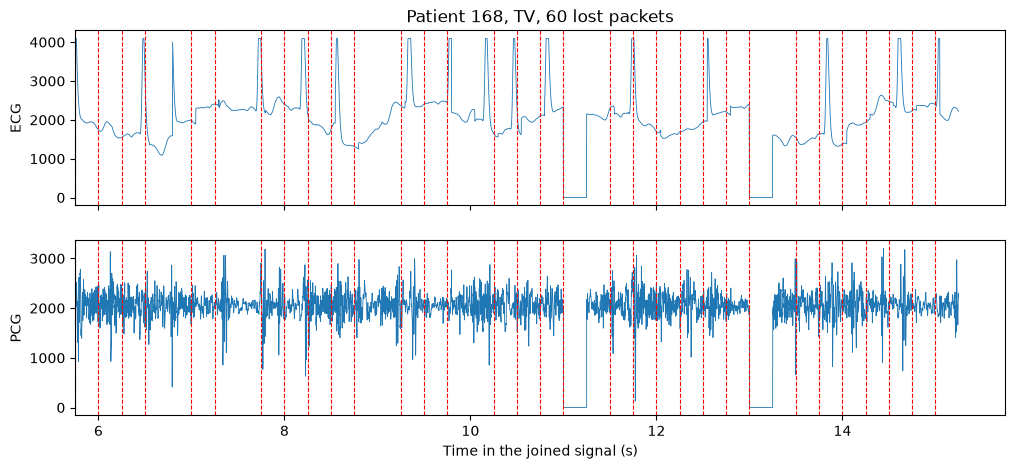

In [17]:
plot_gaps(recordings.loc[recordings["lost_ecg"].idxmax()])

The recording with the most lost packets (patient 168, TV, 60 packets) confirms that the gaps are real:

- **Half of the recording is missing.** The joined signal lasts about 15 s, while the timestamps cover about 29 s, which matches the 60 lost packets (60 × 0.25 s = 15 s).

- **The losses are spread over the whole recording.** There is a red line every 0.25 to 0.5 s, so the connection was unstable the whole time, not interrupted once.

- **The signal jumps at several red lines.** For example, the ECG baseline steps up at about 7.0 and 7.25 s and changes level again at 9.25 s. The signal on either side of these lines does not belong together, so samples are missing there.

- **There are two zero-filled packets**, at about 11.0 and 13.0 s. At both points the signal drops to a flat line at 0 for 0.25 s, at the same time in the ECG and the PCG. These are not recorded values, see [[Section 8.2.]](#82-zero-filled-packets).

- **The beats are irregularly spaced** (for example, two R peaks at about 6.5 and 6.85 s, then a long pause). This comes from the missing stretches between beats, not necessarily from the heart, so any heart rate or RR interval from this recording would be wrong.

So when a packet arrives late, the signal in between is lost, not just delayed. Not every red line shows a visible jump, because a jump only shows when the signal changed during the missing time, but the clear jumps and the zero-filled packets confirm that the timestamps are reliable.

Separately, the R peaks are flat at about 4095, the limit of a 12-bit converter, so the ECG seems to saturate. This is not related to the lost packets.

#### 8.2. Zero-filled packets
[[go back to the topic]](#8-lost-packets)

Most rows have one packet (125 samples in the ECG, 750 in the PCG), but some have two or four. In those rows, every packet except the last is all zeros. So the app sometimes marks a lost packet by filling it with zeros instead of skipping it. The function below counts these packets in each recording.

In [19]:
def count_zero_packets(sig: Signal) -> int:
    """Packets made only of zeros (lost packets the app filled in)."""
    size = int(parse_number(sig.meta["header"]["Packages_size"]))
    packets = sig.data.reshape(-1, size)                 # every row is a whole number of packets
    return int((packets == 0).all(axis=1).sum())

In [20]:
new_app = recordings[(recordings["app"] == "new_app") & recordings["error"].isna()]
zeros = pd.DataFrame([[count_zero_packets(s) for s in load_recording(row)] for _, row in new_app.iterrows()],
                     index=new_app.index, columns=["zeros_ecg", "zeros_pcg"])
recordings = recordings.drop(columns=zeros.columns, errors="ignore").join(zeros)

print("Zero packets (ECG / PCG):", zeros["zeros_ecg"].sum(), "/", zeros["zeros_pcg"].sum())
print("Recordings with zero packets:", (zeros["zeros_ecg"] > 0).sum())
print("Same count in ECG and PCG:", (zeros["zeros_ecg"] == zeros["zeros_pcg"]).all())

Zero packets (ECG / PCG): 314 / 314
Recordings with zero packets: 153
Same count in ECG and PCG: True


The app filled 314 packets with zeros in each signal (78.5 s of signal in total), spread over 153 recordings. The ECG and the PCG have the same count in every recording, so the zeros are inserted at the same moments in both. This is a small part of the lost packets (about 7 000 in total), most are skipped with no trace in the signal, and only some are replaced with zeros.

The count in [[Section 7.2.]](#72-signal-check) already includes them, because a zero packet has no timestamp of its own. The durations do not, the zeros are counted as signal. They will have to be removed or masked before any analysis, because a flat line at 0 is not a real ECG or PCG value.

#### 8.3. The heart cycle in a clean recording
[[go back to the topic]](#8-lost-packets)

The recording in [[Section 8.1.]](#81-plotting-the-gaps) is too damaged to show the heart cycle, so this subsection uses a recording without lost packets (patient 109, MV). One heartbeat has two phases:

- **S1**, the first heart sound, is made by the closing of the mitral and tricuspid valves. It marks the start of **systole**, when the ventricles contract and pump the blood out. It comes right after the R peak of the ECG.
- **S2**, the second heart sound, is made by the closing of the aortic and pulmonary valves. It marks the end of systole and the start of **diastole**, when the ventricles relax and fill again. It comes around the end of the T wave.

The ECG gives the R peaks. The PCG is filtered between 25 and 400 Hz, where most of the energy of the heart sounds is, and its envelope (the absolute value averaged over 40 ms) shows each sound as a bump. S1 is taken as the loudest point in the 150 ms after each R peak, and S2 as the loudest point between 0.2 s after the R peak and roughly the first third of the next interval.

In [29]:
def bandpass(sig: Signal, low: float, high: float, order: int = 2) -> np.ndarray:
    """Keep only the frequencies between low and high (Hz)."""
    b, a = butter(order, [low, high], btype="band", fs=sig.fs)
    return filtfilt(b, a, sig.data)

In [30]:
def find_heart_sounds(ecg: Signal, pcg: Signal):
    """Times (s) of the R peaks, S1 and S2, and the filtered PCG."""
    ecg_f = bandpass(ecg, 0.5, 40)
    r, _ = find_peaks(ecg_f, height=0.6 * np.percentile(ecg_f, 99), distance=0.4 * ecg.fs)
    r = r / ecg.fs

    pcg_f = bandpass(pcg, 25, 400, order=4)
    envelope = pd.Series(np.abs(pcg_f)).rolling(int(0.04 * pcg.fs), center=True).mean()

    def loudest(start, end):
        return envelope.iloc[int(start * pcg.fs):int(end * pcg.fs)].idxmax() / pcg.fs

    s1 = np.array([loudest(t - 0.02, t + 0.15) for t in r[:-1]])
    s2 = np.array([loudest(t + 0.2, t + 0.2 + 0.35 * rr) for t, rr in zip(r, np.diff(r))])
    return r, s1, s2, pcg_f

In [34]:
def plot_heart_cycle(row, start: float, window: float = 4):
    """ECG and filtered PCG with S1, S2, systole (orange) and diastole (blue)."""
    ecg, pcg = load_recording(row)
    r, s1, s2, pcg_f = find_heart_sounds(ecg, pcg)
    top = np.abs(pcg_f).max()
    bpm = 60 / np.median(np.diff(r))

    _, (ax_ecg, ax_pcg) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    ax_ecg.plot(np.arange(len(ecg.data)) / ecg.fs, ecg.data, lw=0.7)
    ax_pcg.plot(np.arange(len(pcg_f)) / pcg.fs, pcg_f, lw=0.4)
    for a, b, c in zip(s1, s2, s1[1:]):          # S1, S2 and the next S1
        for ax in (ax_ecg, ax_pcg):
            ax.axvspan(a, b, color="orange", alpha=0.2)     # systole
            ax.axvspan(b, c, color="tab:blue", alpha=0.1)   # diastole
        ax_pcg.text(a, 1.1 * top, "S1", ha="center", clip_on=True)
        ax_pcg.text(b, 1.1 * top, "S2", ha="center", clip_on=True)
        ax_pcg.text((a + b) / 2, -1.2 * top, "systole", ha="center", color="darkorange", clip_on=True)   # new
        ax_pcg.text((b + c) / 2, -1.2 * top, "diastole", ha="center", color="tab:blue", clip_on=True)    # new
    ax_ecg.set(xlim=(start, start + window), ylabel="ECG",
               title=f"Patient {row['patient']}, {row['site']}, {bpm:.0f} bpm: orange = systole, blue = diastole")
    ax_pcg.set(ylim=(-1.3 * top, 1.3 * top), ylabel="PCG (25-400 Hz)", xlabel="Time (s)")
    plt.show()

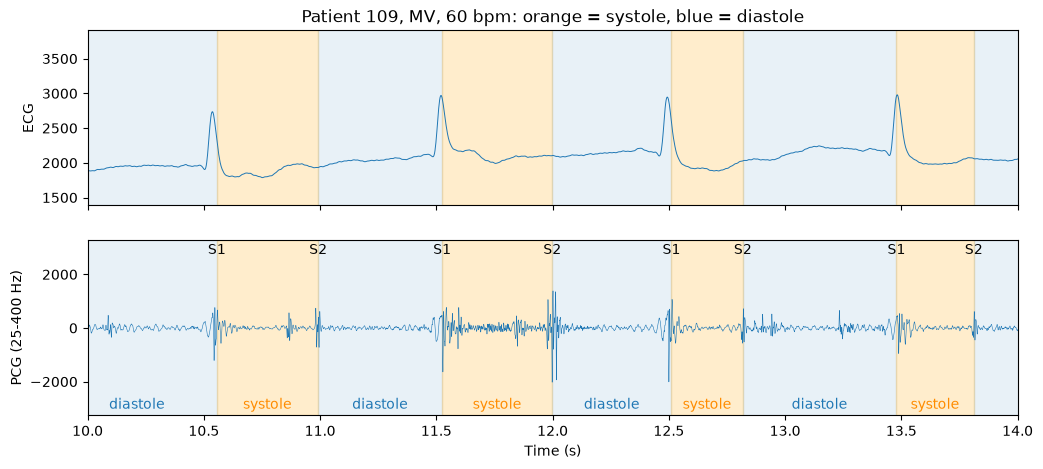

In [35]:
clean = recordings[(recordings["patient"] == 109) & (recordings["site"] == "MV") & (recordings["lost_ecg"] == 0)]
plot_heart_cycle(clean.iloc[0], start=10)

At 60 bpm, the beats are evenly spaced (R peaks about 1 s apart) and S1 falls right on each R peak. Diastole (blue) is longer than systole (orange) in every beat, as expected at a normal heart rate, because the ventricles need more time to fill than to empty. Compared with [[Section 8.1.]](#81-plotting-the-gaps), the signal has no jumps, which is what a recording without lost packets should look like.

The orange bands are not the same width in every beat, in the first two beats systole is clearly longer than in the last two. In those two beats there are two sounds close together near the end of the orange band. The code marks as S2 the loudest sound in a time window after the R peak, and here the second sound is louder, so it is marked as S2. The two sounds could be a split S2 (the aortic and pulmonary valves closing at slightly different times), but this has to be confirmed.

So this detection is only an illustration, it depends on simple rules (loudest point in a time window), it can pick the wrong sound, and in recordings with a weak ECG the R peaks are not found at all. Detecting S1 and S2 reliably needs a dedicated segmentation method, which is out of the scope of this notebook.